In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [3]:
prescribers = pd.read_csv('./top_10_prescribers.csv')

In [4]:
prescribers

,Unnamed: 0,npi,nppes_provider_first_name,nppes_provider_last_org_name,opioid_claims,county,prescriber
0,29044,1912011792,DAVID,COFFEY,9275.0,SCOTT,David Coffey
1,28715,1891915047,JUSTIN,KINDRICK,8405.0,CUMBERLAND,Justin Kindrick
2,14364,1447608211,SHARON,CATHERS,7274.0,KNOX,Sharon Cathers
3,17239,1538428230,MICHELLE,PAINTER,5709.0,SULLIVAN,Michelle Painter
4,30641,1962406793,RICHARD,CLARK,5607.0,FENTRESS,Richard Clark
5,30642,1962406793,RICHARD,CLARK,5607.0,PICKETT,Richard Clark
6,19476,1609879527,JAMES,LADSON,5423.0,RUTHERFORD,James Ladson
7,19075,1598746554,DWIGHT,WILLETT,5221.0,ROANE,Dwight Willett
8,27728,1861892424,ALICIA,TAYLOR,5088.0,CAMPBELL,Alicia Taylor
9,29825,1932279429,AMY,BOWSER,4979.0,SUMNER,Amy Bowser


In [5]:
prescribers = prescribers[['npi', 'opioid_claims', 'county', 'prescriber']].reset_index()

In [6]:
prescribers['county'] = prescribers['county'].str.title()

In [7]:
prescribers

,index,npi,opioid_claims,county,prescriber
0,0,1912011792,9275.0,Scott,David Coffey
1,1,1891915047,8405.0,Cumberland,Justin Kindrick
2,2,1447608211,7274.0,Knox,Sharon Cathers
3,3,1538428230,5709.0,Sullivan,Michelle Painter
4,4,1962406793,5607.0,Fentress,Richard Clark
5,5,1962406793,5607.0,Pickett,Richard Clark
6,6,1609879527,5423.0,Rutherford,James Ladson
7,7,1598746554,5221.0,Roane,Dwight Willett
8,8,1861892424,5088.0,Campbell,Alicia Taylor
9,9,1932279429,4979.0,Sumner,Amy Bowser


In [8]:
grouped = prescribers.groupby('county').agg({'prescriber': ', '.join, 'opioid_claims': 'min'}).reset_index()

In [9]:
counties = gpd.read_file('C:/Users/5pira/Documents/NSS-DDA17/Python/geospatial-rm-pearson/data/county/tncounty.shp')

In [10]:
counties

,OBJECTID,NAME,KEY,SHAPE_AREA,SHAPE_LEN,geometry
0,76,Chester,47023,8.049024e+09,520461.080124,"POLYGON ((1137985.762 344601.643, 1137965.070 ..."
1,77,Wayne,47181,2.050741e+10,666520.678598,"POLYGON ((1365052.057 391716.806, 1365746.554 ..."
2,78,Tipton,47167,1.319125e+10,865093.887634,"MULTIPOLYGON (((886814.330 400456.525, 886774...."
3,79,Hamilton,47065,1.604776e+10,652926.001078,"POLYGON ((2274954.438 239788.911, 2274090.610 ..."
4,80,Stewart,47161,1.375003e+10,490090.336180,"POLYGON ((1382472.783 743972.302, 1382445.171 ..."
...,...,...,...,...,...,...
90,91,McNairy,47109,1.563586e+10,566369.132062,"POLYGON ((1137985.762 344601.643, 1139350.519 ..."
91,92,Franklin,47051,1.605093e+10,621176.096919,"POLYGON ((1873015.265 239618.144, 1872957.848 ..."
92,93,Bradley,47011,9.241234e+09,457372.233476,"POLYGON ((2274954.438 239788.911, 2275552.803 ..."
93,94,Marion,47115,1.428734e+10,529431.591556,"POLYGON ((2126056.390 236919.771, 2122873.509 ..."


In [11]:
merged = pd.merge(counties, grouped, how = 'left', left_on = 'NAME', right_on = 'county')

In [12]:
merged['prescriber'] = merged.prescriber.fillna(' ')

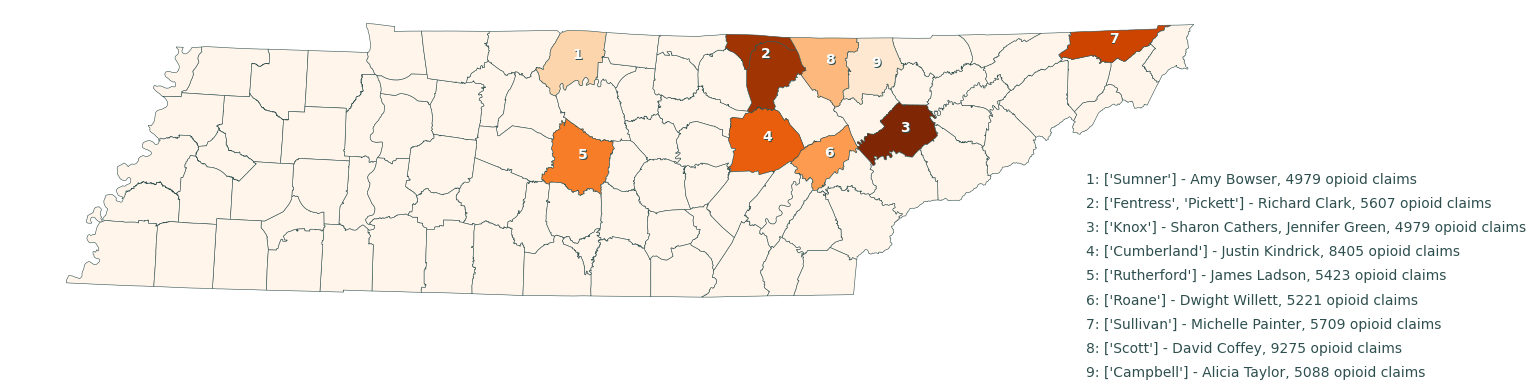

In [129]:
fig, ax = plt.subplots(figsize=(16,4))
merged.plot(ax = ax,
           column = 'prescriber',
           cmap = 'Oranges',
           edgecolor = 'darkslategray',
           linewidth = .4)
ax.axis('off')

n = 1
for prescriber in merged['prescriber'].unique():
    if prescriber != ' ':
        filtered_rows = merged.loc[merged['prescriber'] == prescriber]
        y_pos = filtered_rows.geometry.centroid.y.mean()
        x_pos = filtered_rows.geometry.centroid.x.mean()
        claims = filtered_rows.opioid_claims.mean()
        counties = str(filtered_rows.NAME.to_list())
        
        plt.text(s = n, x = x_pos, y = y_pos, color = 'darkslategray', fontweight = 'semibold')
        plt.text(s = n, x = x_pos - 2000, y = y_pos + 2000, color = 'white', fontweight = 'semibold')
        plt.text(s = str(n) + ': ' + str(counties) + ' - ' + prescriber + ', ' + str(int(claims)) + ' opioid claims', 
                 x = 3000000, 
                 y = 550000 - (55000*n), 
                 color = 'darkslategray')
        
        n += 1

plt.show();

removed from above :
for prescriber in merged['prescriber'].unique():
    if prescriber != ' ':
        filtered_rows = merged.loc[merged['prescriber'] == prescriber]
        y_pos = filtered_rows.geometry.centroid.y.mean()
        x_pos = filtered_rows.geometry.centroid.x.mean()
        text = prescriber

        plt.text(s = text, x = x_pos, y = y_pos, color = 'darkslategray', fontweight = 'semibold')